## Exercise 8 training SVC and SGDClassifier on linear datasets

In [1]:
#create the data
import numpy as np
from matplotlib import pyplot as plt


In [2]:
m = 100
X0 = np.linspace(-3, 3, m)
X1 = np.zeros(shape = X0.shape)
y = np.zeros(shape = X0.shape)
for i in range(len(X0)):
    if X0[i] >= 0:
        X1[i] = X0[i] + np.random.randn()*3 + 5
        y[i] = 1
    else:
        X1[i] = X0[i] + np.random.randn()*3 - 5
X = np.c_[X0, X1]



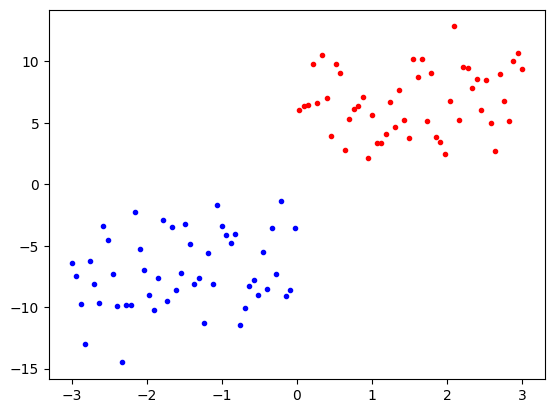

In [3]:
plt.plot(X[y == 0, 0], X[y == 0, 1], 'b.')
plt.plot(X[y == 1, 0], X[y == 1, 1], 'r.')
plt.show()

In [4]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
C = 1
svc_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC(C = 1, loss = 'hinge'))
])
svc_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LinearSVC(C=1, loss='hinge'))])

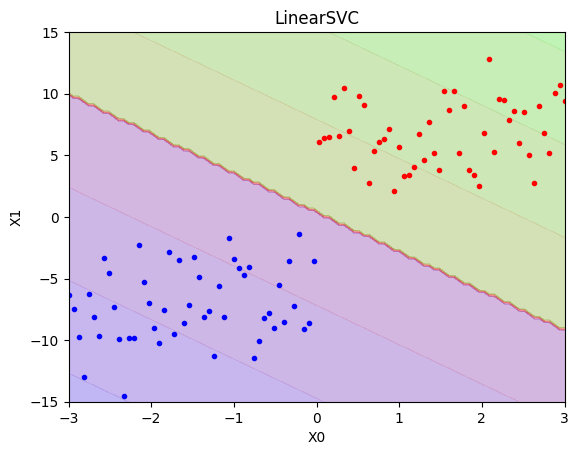

In [5]:
# visualization code is borrowed from the notebooks of the author
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

plot_predictions(svc_clf, [-3, 3, -15, 15])
plt.plot(X[y == 0, 0], X[y == 0, 1], 'b.')
plt.plot(X[y == 1, 0], X[y == 1, 1], 'r.')
plt.title('LinearSVC')
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()


In [6]:
from sklearn.linear_model import SGDClassifier

sgd_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SGDClassifier(alpha = 1/(m*C), loss = 'hinge'))
])

sgd_clf.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SGDClassifier(alpha=0.01))])

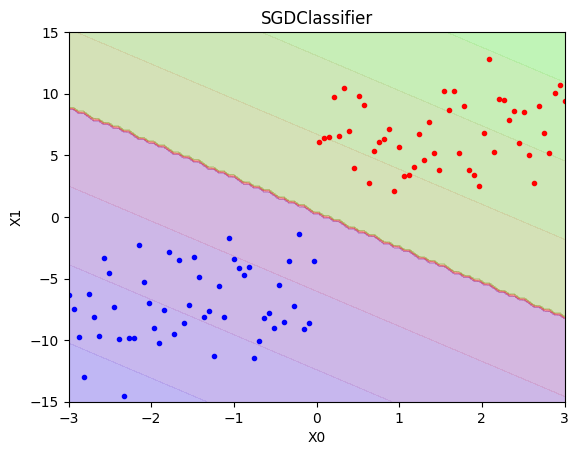

In [7]:
plot_predictions(sgd_clf, [-3, 3, -15, 15])
plt.plot(X[y == 0, 0], X[y == 0, 1], 'b.')
plt.plot(X[y == 1, 0], X[y == 1, 1], 'r.')
plt.title('SGDClassifier')
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

### Using SVMs on MNIST


In [8]:
from sklearn.datasets import fetch_openml

In [9]:
mnist = fetch_openml('mnist_784', version = 1)
X = mnist['data']
y = mnist['target']

In [10]:
X = X.to_numpy()
y = y.to_numpy()

In [17]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

svm_clf_multiclass = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel = 'rbf', verbose = True))
])
svm_clf_multiclass.fit(X_train, y_train)


[LibSVM]*
optimization finished, #iter = 553
obj = -88.604377, rho = -0.263454
nSV = 313, nBSV = 69
.*
optimization finished, #iter = 1862
obj = -295.214840, rho = 0.729366
nSV = 1055, nBSV = 256
.*
optimization finished, #iter = 1653
obj = -238.312714, rho = 0.568384
nSV = 865, nBSV = 194
*.*
optimization finished, #iter = 1238
obj = -172.517765, rho = 0.387459
nSV = 650, nBSV = 122
.*
optimization finished, #iter = 1884
obj = -307.316094, rho = 0.474325
nSV = 953, nBSV = 271
.*
optimization finished, #iter = 1889
obj = -308.499705, rho = 0.667810
nSV = 1019, nBSV = 275
.*
optimization finished, #iter = 1486
obj = -178.015294, rho = 0.717408
nSV = 834, nBSV = 123
.*
optimization finished, #iter = 1554
obj = -269.861026, rho = 0.271408
nSV = 812, nBSV = 218
*.*
optimization finished, #iter = 1242
obj = -219.675863, rho = 0.417824
nSV = 682, nBSV = 190
*.*
optimization finished, #iter = 1326
obj = -271.029520, rho = 0.852918
nSV = 814, nBSV = 279
*.*
optimization finished, #iter = 1146


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(verbose=True))])

In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, svm_clf_multiclass.predict(X_test))

0.9662142857142857